# Store Sales — Time Series Forecasting
### M.Sc. Project Notebook: Classical, ML, and Deep Learning (TFT) Approaches

**Dataset:** [Corporación Favorita Store Sales](https://www.kaggle.com/competitions/store-sales-time-series-forecasting)

**Goal:** Forecast daily unit sales for products across stores, comparing statistical, machine-learning,
and deep-learning (Temporal Fusion Transformer) approaches with a rigorous, reproducible methodology.

---

**How to run this notebook**
1. Download the competition data from Kaggle and place these files in `./data/`:
   `train.csv, test.csv, stores.csv, oil.csv, holidays_events.csv, transactions.csv`
   (or use the Kaggle API: `kaggle competitions download -c store-sales-time-series-forecasting`)
2. Recommended environment: **Kaggle Notebooks** or **Google Colab** (GPU runtime for the TFT section).
3. Install extra dependencies (Section 0) — not all are pre-installed on every platform.

**Notebook structure**
0. Setup & Imports
1. Data Loading & Merging
2. Exploratory Data Analysis (EDA)
3. Seasonal Decomposition
4. Stationarity Testing (ADF, KPSS)
5. Feature Engineering
6. Train / Validation / Test Split (time-based)
7. Baseline Model (seasonal naive)
8. Classical Model: SARIMAX
9. Machine Learning Model: LightGBM
10. Deep Learning Model: LSTM
11. Deep Learning Model: Temporal Fusion Transformer (TFT)
12. Model Comparison & Evaluation
13. Interpretability (feature importance, SHAP, TFT attention)
14. Conclusions & Limitations


## Setup & Imports

In [3]:
# Core
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

In [4]:
!pip install lightgbm


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
!pip install pytorch_forecasting


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import statsmodels.api as sm
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.statespace.sarimax import SARIMAX

import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_squared_log_error
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer, Baseline
from pytorch_forecasting.metrics import RMSE, QuantileLoss
from pytorch_forecasting.data import GroupNormalizer
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping

## 1. Data Loading & Merging

We merge the core `train` table with `stores` (metadata), `oil` (exogenous regressor),
and `holidays_events` (calendar effects) to build a single analysis-ready frame.

In [7]:
train = pd.read_csv(f"train.csv", parse_dates=["date"])
test = pd.read_csv(f"test.csv", parse_dates=["date"])
stores = pd.read_csv(f"stores.csv")
oil = pd.read_csv(f"oil.csv", parse_dates=["date"])
holidays = pd.read_csv(f"holidays_events.csv", parse_dates=["date"])
transactions = pd.read_csv(f"transactions.csv", parse_dates=["date"])

print(train.shape, test.shape)
train.head()

(3000888, 6) (28512, 5)


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [8]:
# Make all date columns datetime
train["date"] = pd.to_datetime(
    train["date"],
    format="%d-%m-%Y"
)

test["date"] = pd.to_datetime(
    test["date"],
    format="%d-%m-%Y"
)

holidays["date"] = pd.to_datetime(
    holidays["date"],
    format="%d-%m-%Y"
)

In [9]:
# Fill missing oil prices (weekends/holidays) via interpolation
oil = oil.set_index("date").reindex(
    pd.date_range(oil.date.min(), oil.date.max(), freq="D")
).rename_axis("date").reset_index()
# reset_index() converts the index back into a normal column

oil["dcoilwtico"] = oil["dcoilwtico"].interpolate().ffill().bfill()

# Simplify holiday calendar: one flag per date (national, non-transferred)
hol = holidays[(holidays.transferred == False) & (holidays.locale == "National")]
hol = hol[["date", "type"]].drop_duplicates("date").rename(columns={"type": "holiday_type"})

def merge_all(df):
    df = df.merge(stores, on="store_nbr", how="left")
    df = df.merge(oil, on="date", how="left")
    df = df.merge(hol, on="date", how="left")
    df["is_holiday"] = df["holiday_type"].notna().astype(int)
    return df

train = merge_all(train)
test = merge_all(test)
train.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,store_type,cluster,dcoilwtico,holiday_type,is_holiday
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,93.14,Holiday,1
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,93.14,Holiday,1
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,93.14,Holiday,1
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,93.14,Holiday,1
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,93.14,Holiday,1


## 2. Exploratory Data Analysis (EDA)

* We start broad (aggregate national sales) then narrow to a single store/family pair,
since the full dataset is ~3M rows across 54 stores × 33 product families.
* onpromotion means the number of products from that product family that were being sold under a promotion/discount on that particular date.

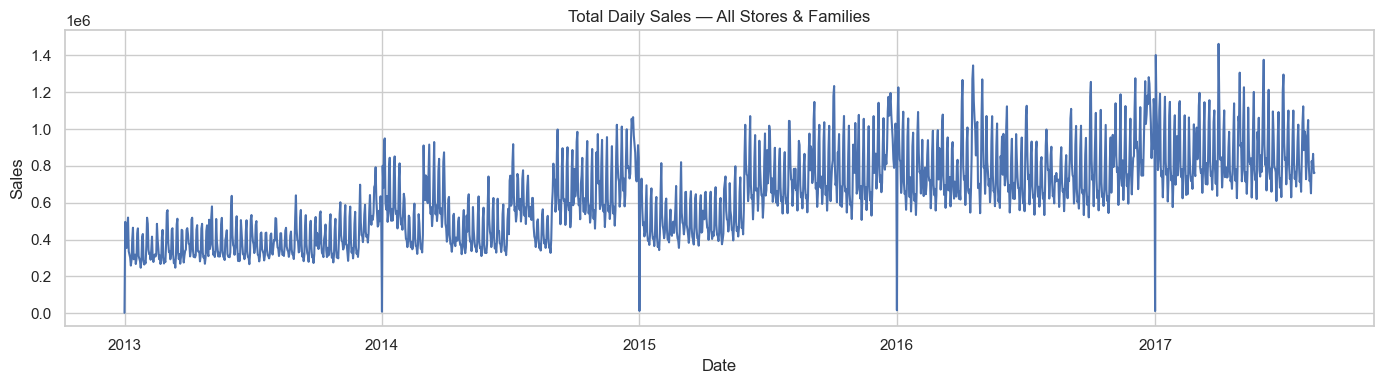

In [10]:
daily_sales = train.groupby("date", as_index=False)["sales"].sum()

plt.figure(figsize=(14, 4))
plt.plot(daily_sales["date"], daily_sales["sales"])
plt.title("Total Daily Sales — All Stores & Families")
plt.xlabel("Date"); plt.ylabel("Sales")
plt.tight_layout()
plt.show()

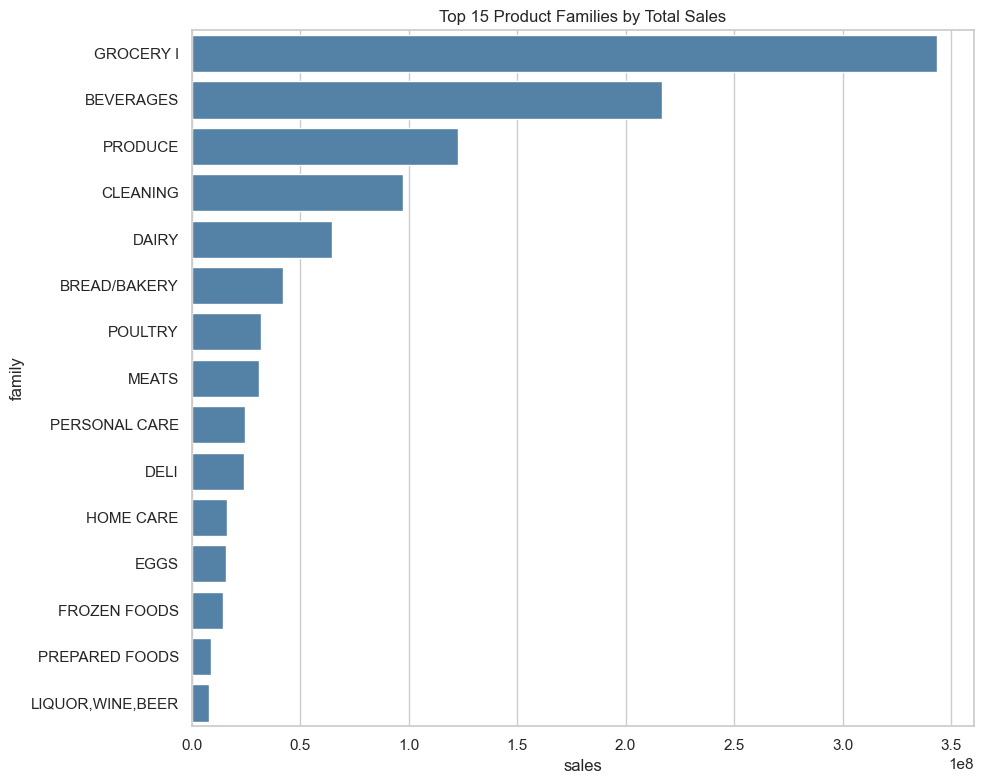

In [11]:
# Sales by product family (top contributors)
fam = train.groupby("family", as_index=False)["sales"].sum().sort_values("sales", ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(data=fam.head(15), y="family", x="sales", color="steelblue")
plt.title("Top 15 Product Families by Total Sales")
plt.tight_layout()
plt.show()


In [12]:
# Missingness & zero-sales check (important: many store/family pairs have zero sales — new products)
print("Missing values:\n", train.isna().sum()[train.isna().sum() > 0]) # Remove columns having zero missing values
print("\n% of zero-sale rows:", (train.sales == 0).mean().round(3))

Missing values:
 holiday_type    2758536
dtype: int64

% of zero-sale rows: 0.313


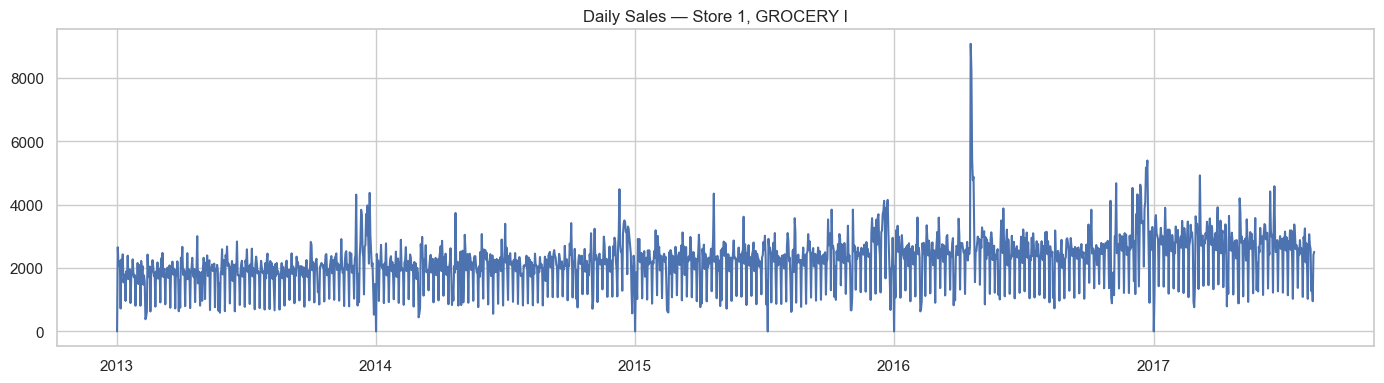

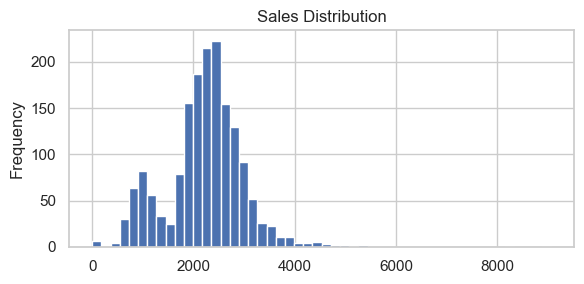

In [13]:
# Focus series for deep-dive: store 1, product family 'GROCERY I'
focus = train[(train.store_nbr == 1) & (train.family == "GROCERY I")].sort_values("date")

plt.figure(figsize=(14, 4))
plt.plot(focus["date"], focus["sales"])
plt.title("Daily Sales — Store 1, GROCERY I")
plt.tight_layout()
plt.show()

focus.set_index("date")["sales"].plot(kind="hist", bins=50, figsize=(6, 3), title="Sales Distribution")
plt.tight_layout()
plt.show()

## 3. Seasonal Decomposition

Using STL (robust to outliers, handles non-integer seasonality better than classical decomposition)
on the focus series to separate trend, weekly seasonality, and residual.

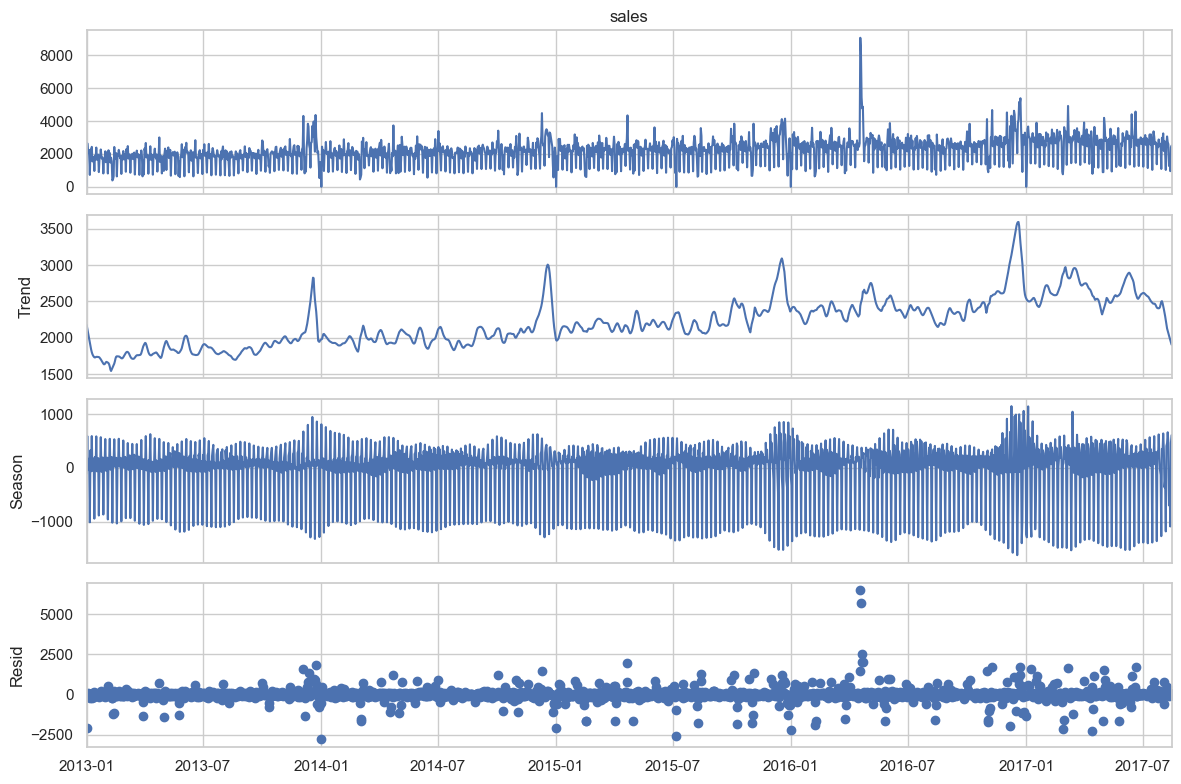

In [14]:
s = focus.set_index("date")["sales"].asfreq("D").interpolate()

stl = STL(s, period=7, robust=True) # robust=True makes STL less sensitive to outliers
res = stl.fit()

fig = res.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

**Interpretation:**
- Is there a long-run trend (growth/decline)?
  * Yes, there is an overall upward trend. The trend component increases from roughly 1,600–1,800 at the beginning of 2013 to around 2,400–2,800 by 2017, although there are several temporary spikes and dips. This indicates that the underlying sales level generally increased over time.
- Is weekly seasonality strong and stable, or does its amplitude change over time (→ multiplicative)?
  * Weekly seasonality is very strong, but its amplitude is not completely stable. The seasonal component shows a clear repeating 7-day pattern throughout the series. However, the magnitude of the seasonal fluctuations becomes larger during some periods, particularly around 2015–2017, when the trend is also higher. This suggests some multiplicative/scale-dependent seasonal behavior, although the STL decomposition shown is additive.
- Are residuals roughly stationary and homoscedastic, or do they show remaining structure (e.g. around holidays)?
  * The residuals are roughly centered around zero, but they are not perfectly homoscedastic. There are several large positive and negative residuals, with some periods showing noticeably greater spread. The large spikes around 2013–2014, 2015, 2016, and especially early 2016 suggest unusual events/outliers that are not fully explained by trend and weekly seasonality. Some of this remaining structure could be associated with holidays, promotions, or other external events.

## 4. Stationarity Testing

We test both the raw series and the STL residual with **ADF** (null: unit root / non-stationary)
and **KPSS** (null: stationary) — using both guards against relying on a single, sometimes
low-powered test.

In [15]:
def stationarity_report(series, name):
    series = series.dropna()
    adf_stat, adf_p, *_ = adfuller(series)
    kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")
    print(f"--- {name} ---")
    print(f"ADF:  stat={adf_stat:.3f}  p-value={adf_p:.4f}  -> {'stationary' if adf_p < 0.05 else 'non-stationary'}")
    print(f"KPSS: stat={kpss_stat:.3f}  p-value={kpss_p:.4f}  -> {'stationary' if kpss_p > 0.05 else 'non-stationary'}")
    print()

stationarity_report(s, "Raw daily sales")
stationarity_report(s.diff(), "First-differenced sales") # Differencing can remove a trend
stationarity_report(res.resid, "STL residual") # After removing trend and weekly seasonality, is the remaining component stationary?

--- Raw daily sales ---
ADF:  stat=-4.132  p-value=0.0009  -> stationary
KPSS: stat=5.947  p-value=0.0100  -> non-stationary

--- First-differenced sales ---
ADF:  stat=-12.359  p-value=0.0000  -> stationary
KPSS: stat=0.189  p-value=0.1000  -> stationary

--- STL residual ---
ADF:  stat=-16.204  p-value=0.0000  -> stationary
KPSS: stat=0.211  p-value=0.1000  -> stationary



## 5. Feature Engineering

Features common to both the LightGBM and TFT models: calendar features, lags, rolling
statistics, and exogenous regressors (oil price, holiday flag, promotions).

In [16]:
def add_time_features(df):
    df = df.copy()
    df["dayofweek"] = df["date"].dt.dayofweek
    df["day"] = df["date"].dt.day
    df["month"] = df["date"].dt.month
    df["year"] = df["date"].dt.year
    df["weekofyear"] = df["date"].dt.isocalendar().week.astype(int)
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
    df["is_month_start"] = df["date"].dt.is_month_start.astype(int)
    df["is_month_end"] = df["date"].dt.is_month_end.astype(int)
    return df

def add_lag_roll_features(df, group_cols, target="sales", lags=(1, 7, 14, 28), windows=(7, 28)):
    df = df.sort_values(group_cols + ["date"]).copy()
    g = df.groupby(group_cols)[target]
    for lag in lags:
        df[f"lag_{lag}"] = g.shift(lag)
    for w in windows:
        df[f"rollmean_{w}"] = g.transform(lambda s: s.shift(1).rolling(w).mean())
        df[f"rollstd_{w}"]  = g.transform(lambda s: s.shift(1).rolling(w).std())
    return df

train_fe = add_time_features(train)
train_fe = add_lag_roll_features(train_fe, ["store_nbr", "family"])
train_fe = train_fe.dropna(subset=[c for c in train_fe.columns if c.startswith("lag_")])
train_fe.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,store_type,cluster,dcoilwtico,holiday_type,is_holiday,dayofweek,day,month,year,weekofyear,is_weekend,is_month_start,is_month_end,lag_1,lag_7,lag_14,lag_28,rollmean_7,rollstd_7,rollmean_28,rollstd_28
49896,49896,2013-01-29,1,AUTOMOTIVE,2.0,0,Quito,Pichincha,D,13,97.620000,NaN,0,1,29,1,2013,5,0,0,0,3.0,1.0,1.0,0.0,2.571429,1.718249,2.142857,1.458418
51678,51678,2013-01-30,1,AUTOMOTIVE,6.0,0,Quito,Pichincha,D,13,97.980000,NaN,0,2,30,1,2013,5,0,0,0,2.0,3.0,1.0,2.0,2.714286,1.603567,2.214286,1.397276
53460,53460,2013-01-31,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,97.650000,NaN,0,3,31,1,2013,5,0,0,1,6.0,0.0,1.0,3.0,3.142857,2.035401,2.357143,1.568540
55242,55242,2013-02-01,1,AUTOMOTIVE,3.0,0,Quito,Pichincha,D,13,97.460000,NaN,0,4,1,2,2013,5,0,1,0,0.0,5.0,0.0,3.0,3.142857,2.035401,2.250000,1.624466
57024,57024,2013-02-02,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,97.043333,NaN,0,5,2,2,2013,5,1,0,0,3.0,4.0,5.0,5.0,2.857143,1.864454,2.250000,1.624466


## 6. Train / Validation / Test Split (Time-Based)

**No random shuffling.** We hold out the most recent contiguous period for validation and
the last block (matching the competition's 15-day horizon) for testing, to mimic real deployment.

In [17]:
cutoff_val = train_fe["date"].max() - pd.Timedelta(days=30)
cutoff_test = train_fe["date"].max() - pd.Timedelta(days=15)

train_set = train_fe[train_fe.date <= cutoff_val]
val_set   = train_fe[(train_fe.date > cutoff_val) & (train_fe.date <= cutoff_test)]
test_set  = train_fe[train_fe.date > cutoff_test]

print("Train:", train_set.date.min(), "-", train_set.date.max(), len(train_set))
print("Val:  ", val_set.date.min(), "-", val_set.date.max(), len(val_set))
print("Test: ", test_set.date.min(), "-", test_set.date.max(), len(test_set))

Train: 2013-01-29 00:00:00 - 2017-07-16 00:00:00 2897532
Val:   2017-07-17 00:00:00 - 2017-07-31 00:00:00 26730
Test:  2017-08-01 00:00:00 - 2017-08-15 00:00:00 26730


## 7. Baseline Model — Seasonal Naive

Forecast = sales from the same weekday, previous week. Every subsequent model must beat this
to justify its added complexity.

In [18]:
def rmsle(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

def evaluate(y_true, y_pred, name):
    y_pred = np.clip(y_pred, 0, None)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    rmsle_v = rmsle(y_true, y_pred)
    print(f"{name:20s}  RMSE={rmse:10.3f}  MAE={mae:10.3f}  RMSLE={rmsle_v:.4f}")
    return {"model": name, "RMSE": rmse, "MAE": mae, "RMSLE": rmsle_v}

results = []

focus_val = val_set[(val_set.store_nbr == 1) & (val_set.family == "GROCERY I")]
naive_pred = focus_val["lag_7"]
results.append(evaluate(focus_val["sales"], naive_pred, "Seasonal Naive"))

Seasonal Naive        RMSE=   373.860  MAE=   284.333  RMSLE=0.1564


## 8. Classical Models — ARIMA, SARIMA, SARIMAX & Prophet

Four classical/statistical baselines fit on the focus series (Store 1, GROCERY I), in order
of increasing complexity: a plain **ARIMA**, then a seasonal **SARIMA**, then **SARIMAX**
which adds exogenous regressors (oil price, holiday flag) on top of the same seasonal
structure, and finally **Prophet** as an alternative, decomposition-based approach fit with
the same two regressors. Each is evaluated on the same validation window as the
seasonal-naive baseline above.

In [19]:
focus_train = train_set[(train_set.store_nbr == 1) & (train_set.family == "GROCERY I")].set_index("date")
focus_val_s = val_set[(val_set.store_nbr == 1) & (val_set.family == "GROCERY I")].set_index("date")

exog_train = focus_train[["dcoilwtico", "is_holiday"]]
exog_val = focus_val_s[["dcoilwtico", "is_holiday"]]

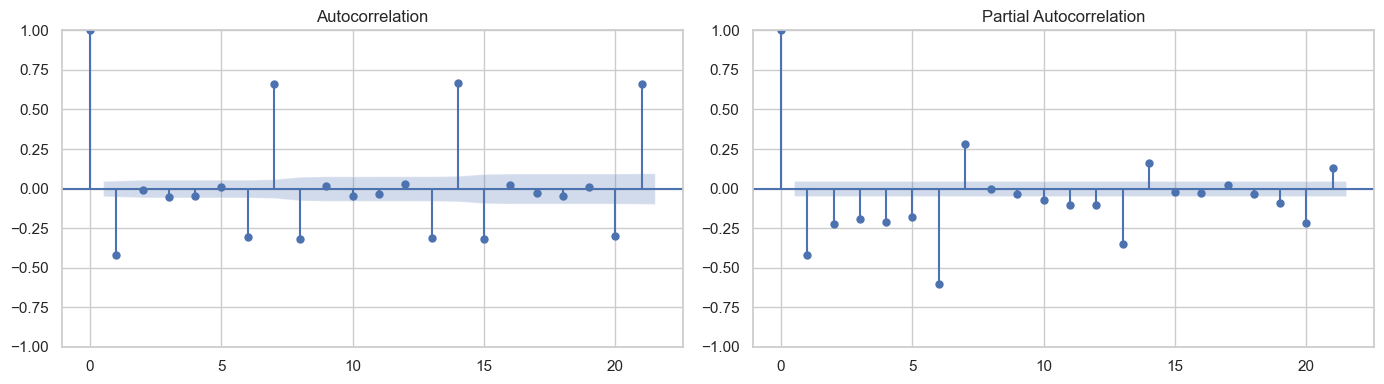

In [20]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(s.diff().dropna(), lags=21, ax=axes[0])
plot_pacf(s.diff().dropna(), lags=21, ax=axes[1])
plt.tight_layout()
plt.show()

### 8.1 Classical Model — ARIMA (non-seasonal)

A plain `ARIMA(p, d, q)` fit on the focus series alone (Store 1, GROCERY I), with **no
seasonal terms and no exogenous regressors** — the simplest classical model beyond
seasonal-naive, and a useful stepping stone before adding seasonality (SARIMA) and
exogenous inputs (SARIMAX). The order is chosen with `pmdarima.auto_arima` (stepwise AIC
search); if `pmdarima` isn't installed we fall back to a fixed `(1,1,1)` order.

In [21]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA(1,1,1)
arima_model = ARIMA(
    focus_train["sales"],
    order=(1, 1, 1)
)

arima_fit = arima_model.fit()

print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                 1626
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -12987.129
Date:                Sun, 09 Aug 2026   AIC                          25980.258
Time:                        20:35:57   BIC                          25996.438
Sample:                             0   HQIC                         25986.261
                               - 1626                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1802      0.016     11.446      0.000       0.149       0.211
ma.L1         -0.9833      0.004   -257.900      0.000      -0.991      -0.976
sigma2      5.111e+05   9807.297     52.112      0.0

ARIMA(1,1,1)          RMSE=   590.930  MAE=   385.886  RMSLE=0.3018


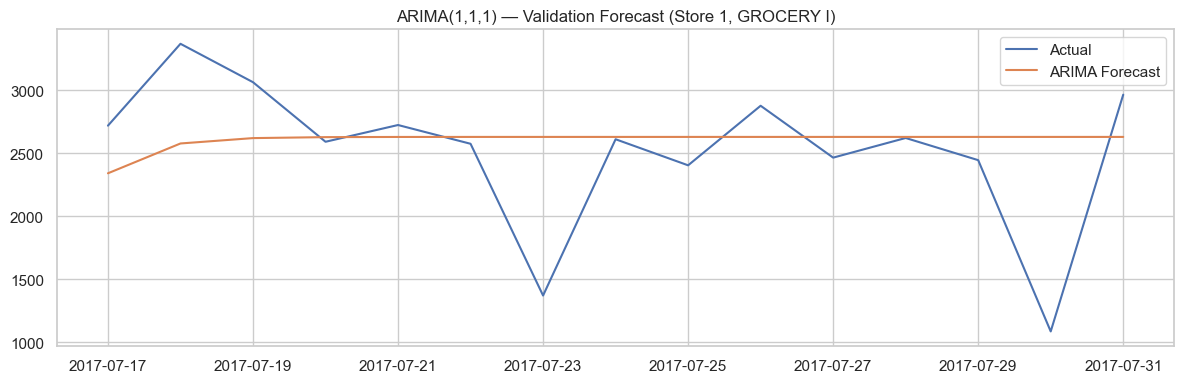

In [27]:
arima_pred = arima_fit.forecast(steps=len(focus_val_s))
arima_pred.index = focus_val_s.index
results.append(evaluate(focus_val_s["sales"], arima_pred, "ARIMA(1,1,1)"))

plt.figure(figsize=(12, 4))
plt.plot(focus_val_s.index, focus_val_s["sales"], label="Actual")
plt.plot(focus_val_s.index, arima_pred, label="ARIMA Forecast")
plt.legend()
plt.title(f"ARIMA(1,1,1) — Validation Forecast (Store 1, GROCERY I)")
plt.tight_layout()
plt.show()

In [31]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

best_rmse = np.inf
best_order = None
best_fit = None

for p in range(0, 7):
    for d in range(0, 5):
        for q in range(0, 7):

            try:
                model = ARIMA(
                    focus_train["sales"],
                    order=(p, d, q)
                )

                fit = model.fit()

                pred = fit.forecast(
                    steps=len(focus_val_s)
                )

                rmse = np.sqrt(
                    mean_squared_error(
                        focus_val_s["sales"],
                        pred
                    )
                )

                if rmse < best_rmse:
                    best_rmse = rmse
                    best_order = (p, d, q)
                    best_fit = fit

            except Exception:
                continue

print("Best ARIMA order:", best_order)
print("Best validation RMSE:", best_rmse)

Best ARIMA order: (6, 2, 5)
Best validation RMSE: 317.31200726772227


In [32]:
arima_pred = best_fit.forecast(
    steps=len(focus_val_s)
)

arima_pred.index = focus_val_s.index

results.append(
    evaluate(
        focus_val_s["sales"],
        arima_pred,
        f"ARIMA{best_order}"
    )
)

ARIMA(6, 2, 5)        RMSE=   317.312  MAE=   238.861  RMSLE=0.1442


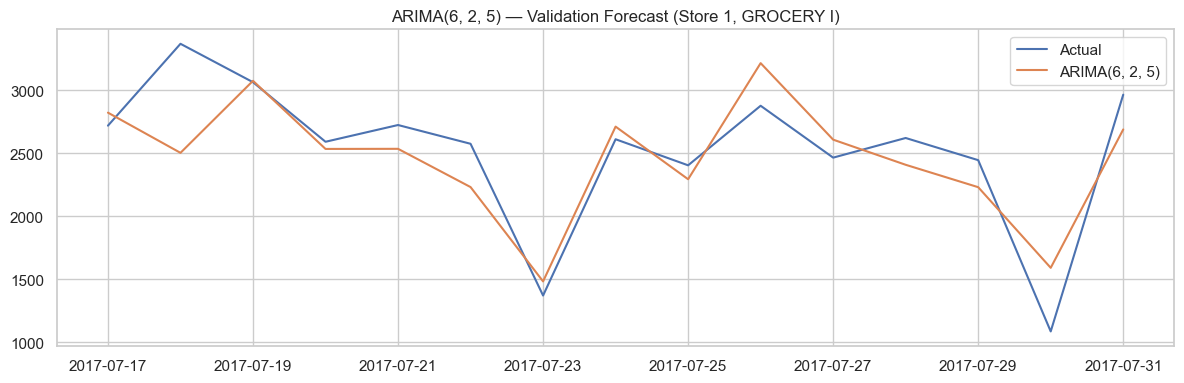

In [33]:
plt.figure(figsize=(12, 4))

plt.plot(
    focus_val_s.index,
    focus_val_s["sales"],
    label="Actual"
)

plt.plot(
    focus_val_s.index,
    arima_pred,
    label=f"ARIMA{best_order}"
)

plt.legend()
plt.title(
    f"ARIMA{best_order} — Validation Forecast "
    "(Store 1, GROCERY I)"
)

plt.tight_layout()
plt.show()

### 8.2 Classical Model — SARIMA (seasonal, no exogenous regressors)

Same seasonal specification as the SARIMAX model below — order `(1,1,1)` with weekly
seasonal order `(1,1,1,7)` — but fit **without** the oil-price / holiday exogenous
regressors. Comparing this against SARIMAX in the leaderboard isolates how much those
exogenous inputs actually help over pure seasonal autoregression.

c:\Users\badal\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\badal\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\badal\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


SARIMA                RMSE=   269.710  MAE=   231.280  RMSLE=0.1035


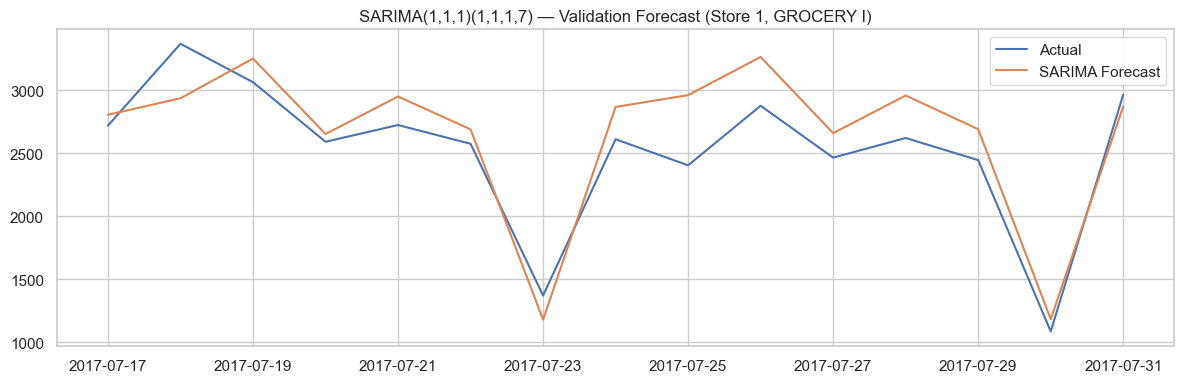

In [ ]:
sarima = SARIMAX(
    focus_train["sales"],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_fit = sarima.fit(disp=False)

sarima_pred = sarima_fit.forecast(steps=len(focus_val_s))
sarima_pred.index = focus_val_s.index
results.append(evaluate(focus_val_s["sales"], sarima_pred, "SARIMA"))

plt.figure(figsize=(12, 4))
plt.plot(focus_val_s.index, focus_val_s["sales"], label="Actual")
plt.plot(focus_val_s.index, sarima_pred, label="SARIMA Forecast")
plt.legend()
plt.title("SARIMA(1,1,1)(1,1,1,7) — Validation Forecast (Store 1, GROCERY I)")
plt.tight_layout()
plt.show()

In [34]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import numpy as np
import warnings

warnings.filterwarnings("ignore")

best_rmse = np.inf
best_order = None
best_seasonal_order = None
best_fit = None

# Non-seasonal parameters
p_values = [0, 1, 2]
d_values = [0, 1]
q_values = [0, 1, 2]

# Seasonal parameters
P_values = [0, 1]
D_values = [0, 1]
Q_values = [0, 1]

seasonal_period = 7

for p in p_values:
    for d in d_values:
        for q in q_values:

            for P in P_values:
                for D in D_values:
                    for Q in Q_values:

                        order = (p, d, q)
                        seasonal_order = (P, D, Q, seasonal_period)

                        try:
                            model = SARIMAX(
                                focus_train["sales"],
                                order=order,
                                seasonal_order=seasonal_order,
                                enforce_stationarity=False,
                                enforce_invertibility=False
                            )

                            fit = model.fit(disp=False)

                            pred = fit.forecast(
                                steps=len(focus_val_s)
                            )

                            rmse = np.sqrt(
                                mean_squared_error(
                                    focus_val_s["sales"],
                                    pred
                                )
                            )

                            if rmse < best_rmse:
                                best_rmse = rmse
                                best_order = order
                                best_seasonal_order = seasonal_order
                                best_fit = fit

                        except Exception:
                            continue

print("Best SARIMA order:", best_order)
print(
    "Best seasonal order:",
    best_seasonal_order
)
print("Best validation RMSE:", best_rmse)

Best SARIMA order: (0, 1, 1)
Best seasonal order: (1, 1, 1, 7)
Best validation RMSE: 223.3962773633114


In [35]:
sarima_pred = best_fit.forecast(
    steps=len(focus_val_s)
)

sarima_pred.index = focus_val_s.index

results.append(
    evaluate(
        focus_val_s["sales"],
        sarima_pred,
        f"SARIMA{best_order}{best_seasonal_order}"
    )
)

SARIMA(0, 1, 1)(1, 1, 1, 7)  RMSE=   223.396  MAE=   154.763  RMSLE=0.1063


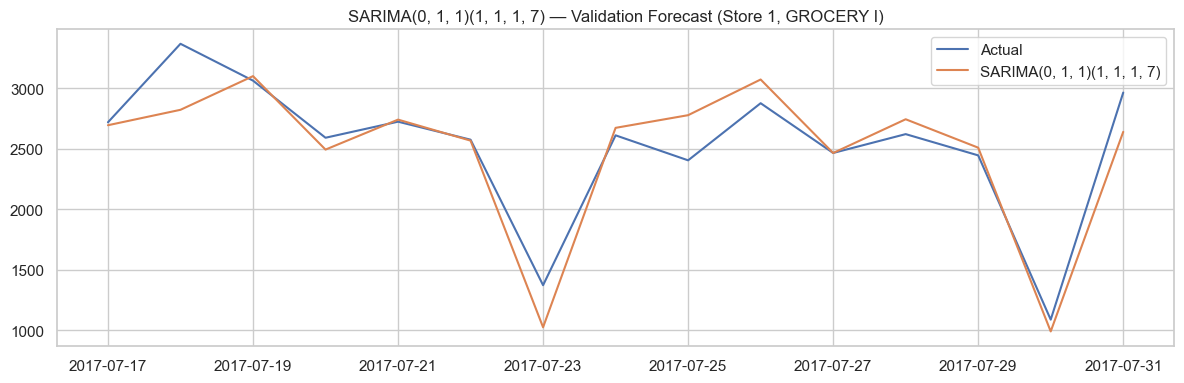

In [36]:
plt.figure(figsize=(12, 4))

plt.plot(
    focus_val_s.index,
    focus_val_s["sales"],
    label="Actual"
)

plt.plot(
    focus_val_s.index,
    sarima_pred,
    label=f"SARIMA{best_order}{best_seasonal_order}"
)

plt.legend()

plt.title(
    f"SARIMA{best_order}{best_seasonal_order} "
    "— Validation Forecast (Store 1, GROCERY I)"
)

plt.tight_layout()
plt.show()

### 8.3 Classical Model — SARIMAX (seasonal + exogenous regressors)

Same `(0,1,1)(1,1,1,7)` seasonal order as SARIMA above, plus `dcoilwtico` (oil price) and
`is_holiday` as exogenous regressors — isolating how much those extra inputs help once
weekly seasonality is already accounted for.

In [39]:
sarimax = SARIMAX(
    focus_train["sales"],
    exog=exog_train,
    order=(0, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarimax_fit = sarimax.fit(disp=False)
print(sarimax_fit.summary())

                                     SARIMAX Results                                     
Dep. Variable:                             sales   No. Observations:                 1626
Model:             SARIMAX(0, 1, 1)x(1, 1, 1, 7)   Log Likelihood              -12369.163
Date:                           Sun, 09 Aug 2026   AIC                          24750.326
Time:                                   21:04:19   BIC                          24782.627
Sample:                                        0   HQIC                         24762.317
                                          - 1626                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
dcoilwtico    -9.9813     11.038     -0.904      0.366     -31.615      11.652
is_holiday  -680.8534     32.752    -20.788

SARIMAX               RMSE=   235.317  MAE=   163.694  RMSLE=0.1190


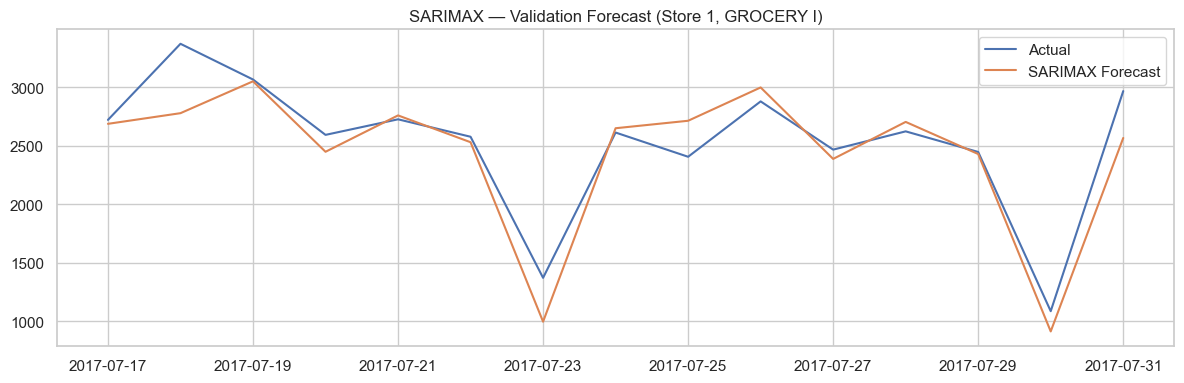

In [40]:
sarimax_pred = sarimax_fit.forecast(steps=len(focus_val_s), exog=exog_val)
results.append(evaluate(focus_val_s["sales"], sarimax_pred, "SARIMAX"))

plt.figure(figsize=(12, 4))
plt.plot(focus_val_s.index, focus_val_s["sales"], label="Actual")
plt.plot(focus_val_s.index, sarimax_pred, label="SARIMAX Forecast")
plt.legend()
plt.title("SARIMAX — Validation Forecast (Store 1, GROCERY I)")
plt.tight_layout()
plt.show()

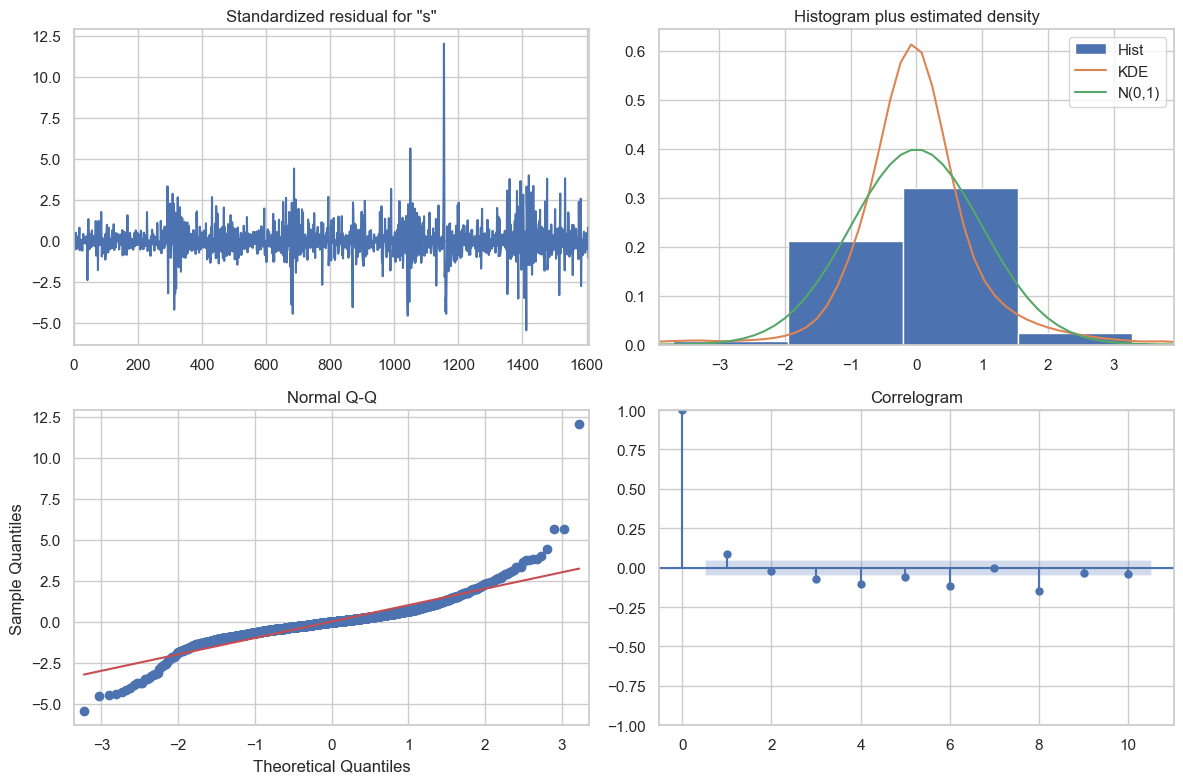

       lb_stat     lb_pvalue
10  101.267771  3.037477e-17


In [41]:
# Residual diagnostics
resid = sarimax_fit.resid
fig = sarimax_fit.plot_diagnostics(figsize=(12, 8))
plt.tight_layout(); plt.show()

lb = sm.stats.acorr_ljungbox(resid, lags=[10], return_df=True)
print(lb)  # p > 0.05 => residuals behave like white noise (good)

### 8.4 Classical Model — Prophet

Prophet decomposes the series into trend + weekly/yearly seasonality + holiday effects,
fit with an additive curve-fitting approach rather than an ARMA process. It's included
here as a widely-used, low-tuning-effort alternative to the ARIMA family, and it accepts
the same oil price and holiday flag as extra regressors.

In [42]:
!pip install prophet


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


21:04:51 - cmdstanpy - INFO - Chain [1] start processing
21:04:52 - cmdstanpy - INFO - Chain [1] done processing


Prophet               RMSE=   226.206  MAE=   175.337  RMSLE=0.0925


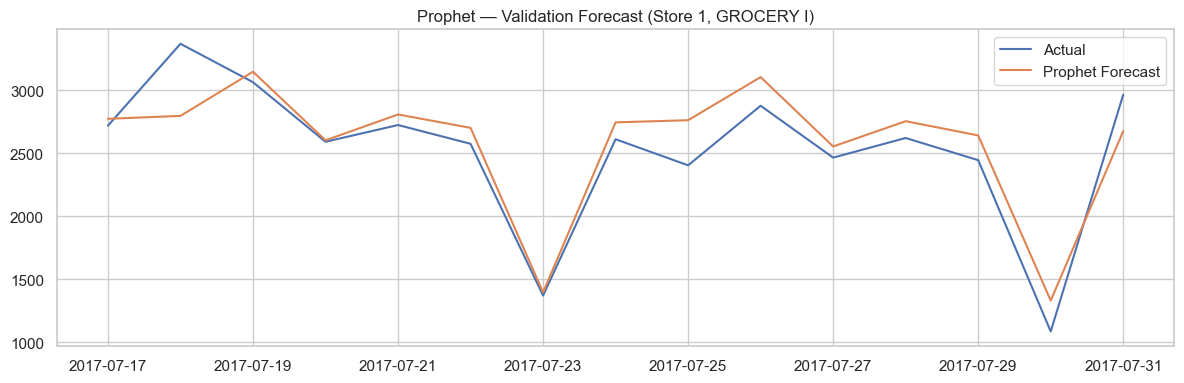

In [ ]:
from prophet import Prophet

prophet_train_df = focus_train.reset_index()[["date", "sales", "dcoilwtico", "is_holiday"]].rename(
    columns={"date": "ds", "sales": "y"}
)
prophet_val_df = focus_val_s.reset_index()[["date", "dcoilwtico", "is_holiday"]].rename(columns={"date": "ds"})

prophet_model = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
prophet_model.add_regressor("dcoilwtico")
prophet_model.add_regressor("is_holiday")
prophet_model.fit(prophet_train_df)

prophet_forecast = prophet_model.predict(prophet_val_df)
prophet_pred = prophet_forecast["yhat"].values
results.append(evaluate(focus_val_s["sales"].values, prophet_pred, "Prophet"))

plt.figure(figsize=(12, 4))
plt.plot(focus_val_s.index, focus_val_s["sales"].values, label="Actual")
plt.plot(focus_val_s.index, prophet_pred, label="Prophet Forecast")
plt.legend()
plt.title("Prophet — Validation Forecast (Store 1, GROCERY I)")
plt.tight_layout()
plt.show()

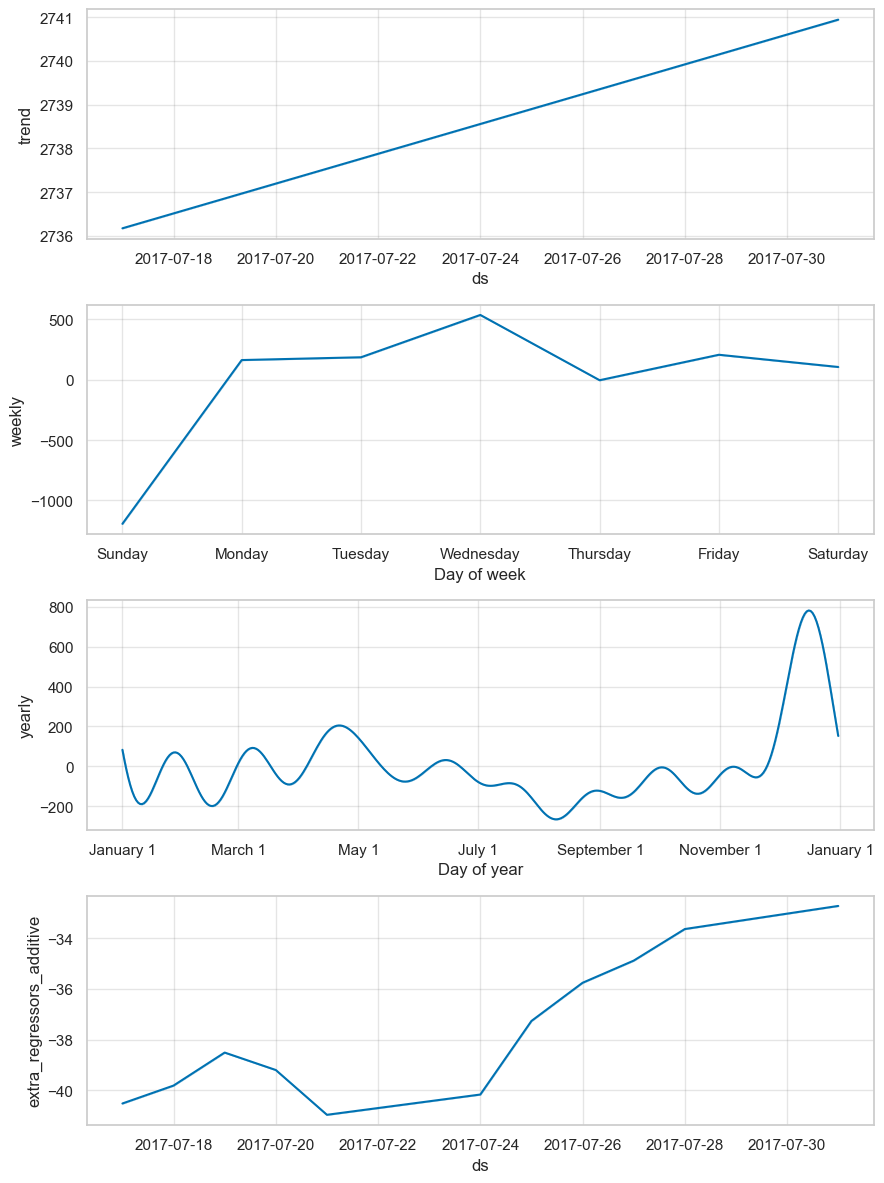

In [44]:
fig = prophet_model.plot_components(prophet_forecast)
plt.tight_layout()
plt.show()

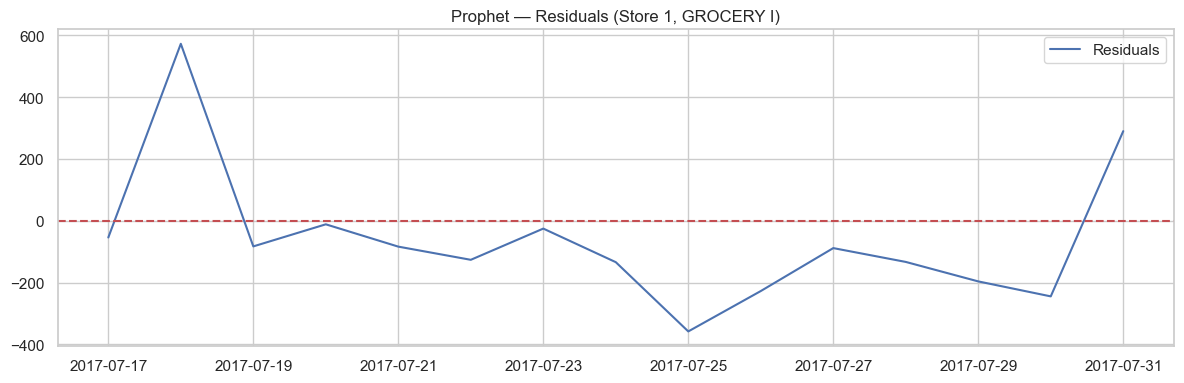

In [54]:
from prophet.plot import plot_plotly, plot_components_plotly

# Interactive forecast plot (zoomable)
fig = plot_plotly(prophet_model, prophet_forecast)
fig.show()

# Interactive components plot
fig2 = plot_components_plotly(prophet_model, prophet_forecast)
fig2.show()

# Residuals over time
residuals = focus_val_s["sales"].values - prophet_pred
plt.figure(figsize=(12, 4))
plt.plot(focus_val_s.index, residuals, label="Residuals")
plt.axhline(0, color="r", linestyle="--")
plt.title("Prophet — Residuals (Store 1, GROCERY I)")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Machine Learning Model — LightGBM

Gradient-boosted trees trained globally across all store/family series, using lag, rolling,
and calendar features. This tends to outperform per-series classical models when many
related series share structure (cross-learning).

In [ ]:
cat_cols = ["family", "city", "state", "store_type", "store_nbr"]
encoders = {}
for c in cat_cols:
    le = LabelEncoder()
    all_vals = pd.concat([train_fe[c], test[c]]).astype(str).unique()
    le.fit(all_vals)
    encoders[c] = le
    train_fe[c + "_enc"] = le.transform(train_fe[c].astype(str))

feature_cols = (
    [f"{c}_enc" for c in cat_cols]
    + ["dayofweek", "day", "month", "year", "weekofyear", "is_weekend",
       "is_month_start", "is_month_end", "onpromotion", "dcoilwtico", "is_holiday"]
    + [c for c in train_fe.columns if c.startswith("lag_") or c.startswith("roll")]
)

X_train, y_train = train_set[feature_cols_avail := [c for c in feature_cols if c in train_set.columns]], train_set["sales"]
X_val, y_val = val_set[feature_cols_avail], val_set["sales"]

lgb_train = lgb.Dataset(X_train, label=np.log1p(y_train))
lgb_val = lgb.Dataset(X_val, label=np.log1p(y_val), reference=lgb_train)

params = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.05,
    "num_leaves": 63,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "verbose": -1,
    "seed": 42,
}

lgb_model = lgb.train(
    params, lgb_train, num_boost_round=2000, valid_sets=[lgb_val],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 0.389401
[200]	valid_0's rmse: 0.38779
[300]	valid_0's rmse: 0.386475
[400]	valid_0's rmse: 0.385673
[500]	valid_0's rmse: 0.38511
[600]	valid_0's rmse: 0.384826
[700]	valid_0's rmse: 0.384565
[800]	valid_0's rmse: 0.384337
[900]	valid_0's rmse: 0.384186
[1000]	valid_0's rmse: 0.384095
[1100]	valid_0's rmse: 0.383984
[1200]	valid_0's rmse: 0.383772
[1300]	valid_0's rmse: 0.383673
[1400]	valid_0's rmse: 0.383561
Early stopping, best iteration is:
[1424]	valid_0's rmse: 0.383512


In [ ]:
lgb_val_pred = np.expm1(lgb_model.predict(X_val, num_iteration=lgb_model.best_iteration))
results.append(evaluate(y_val, lgb_val_pred, "LightGBM (global)"))

# Same-series comparison for a fair look against SARIMAX/naive
mask = (val_set.store_nbr == 1) & (val_set.family == "GROCERY I")
results.append(evaluate(y_val[mask], lgb_val_pred[mask.values], "LightGBM (focus series)"))

LightGBM (global)     RMSE=   195.282  MAE=    53.806  RMSLE=0.3835
LightGBM (focus series)  RMSE=   233.092  MAE=   179.826  RMSLE=0.0942


## 10. Deep Learning Model — LSTM

A sequence-to-one LSTM as a simpler deep-learning baseline before TFT: it takes a fixed
lookback window of past sales (+ a few exogenous features) and predicts the next step,
used recursively to generate a multi-step forecast. Trained per-series here on the focus
series (store 1, GROCERY I) to keep things simple and comparable to SARIMAX; a global
variant (all series, with a series-ID embedding) is sketched at the end as an extension.

In [ ]:
from sklearn.preprocessing import StandardScaler

LOOKBACK = 28
HORIZON = 1  # trained as one-step-ahead, then forecast recursively over the validation window

lstm_series = pd.concat([focus_train.reset_index(), focus_val_s.reset_index()], ignore_index=True)
feat_cols_lstm = ["sales", "dcoilwtico", "is_holiday", "onpromotion"]
lstm_series = lstm_series[["date"] + feat_cols_lstm].copy()

scaler = StandardScaler()
train_len = len(focus_train)
scaler.fit(lstm_series.loc[:train_len - 1, feat_cols_lstm])
lstm_series[feat_cols_lstm] = scaler.transform(lstm_series[feat_cols_lstm])

def make_windows(arr, lookback):
    X, y = [], []
    for i in range(lookback, len(arr)):
        X.append(arr[i - lookback:i, :])
        y.append(arr[i, 0])  # target = sales (col 0)
    return np.array(X), np.array(y)

values = lstm_series[feat_cols_lstm].values
X_all, y_all = make_windows(values, LOOKBACK)

# Align split so the validation windows only look back into train (no leakage from val into val)
n_val = len(focus_val_s)
X_train_l, y_train_l = X_all[:-n_val], y_all[:-n_val]
X_val_l, y_val_l = X_all[-n_val:], y_all[-n_val:]

print(X_train_l.shape, X_val_l.shape)

(1598, 28, 4) (15, 28, 4)


In [ ]:
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader_lstm = DataLoader(SeqDataset(X_train_l, y_train_l), batch_size=32, shuffle=True)
val_loader_lstm = DataLoader(SeqDataset(X_val_l, y_val_l), batch_size=32, shuffle=False)

class LSTMForecaster(nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features, hidden_size=hidden_size, num_layers=num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(nn.Linear(hidden_size, 32), nn.ReLU(), nn.Linear(32, 1))

    def forward(self, x):
        out, _ = self.lstm(x)
        last_step = out[:, -1, :]
        return self.head(last_step).squeeze(-1)


device = "cuda" if torch.cuda.is_available() else "cpu"
lstm_model = LSTMForecaster(n_features=X_train_l.shape[-1]).to(device)
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

Epoch   1  train_loss=0.9155  val_loss=0.5460
Epoch   6  train_loss=0.8631  val_loss=0.5449
Epoch  11  train_loss=0.8005  val_loss=0.5147
Epoch  16  train_loss=0.4015  val_loss=0.1059
Epoch  21  train_loss=0.3295  val_loss=0.1553
Epoch  26  train_loss=0.2853  val_loss=0.0890
Early stopping at epoch 31


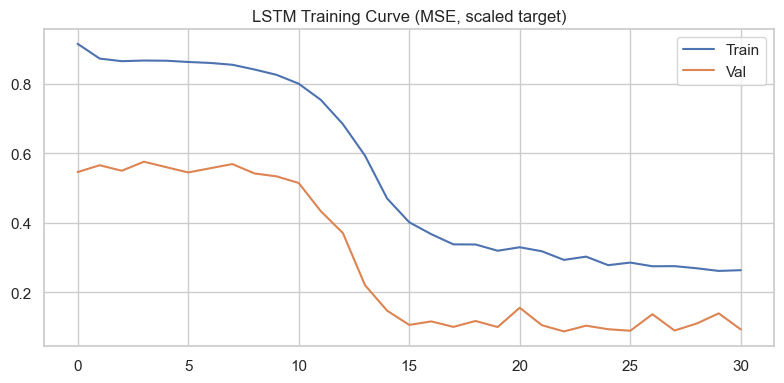

In [ ]:
def run_epoch(loader, train_mode=True):
    lstm_model.train(train_mode)
    total_loss, n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        if train_mode:
            optimizer.zero_grad()
        pred = lstm_model(xb)
        loss = criterion(pred, yb)
        if train_mode:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * len(xb)
        n += len(xb)
    return total_loss / n

N_EPOCHS = 40
best_val = np.inf
patience, patience_ctr = 8, 0
history = {"train": [], "val": []}

for epoch in range(N_EPOCHS):
    tr_loss = run_epoch(train_loader_lstm, train_mode=True)
    with torch.no_grad():
        va_loss = run_epoch(val_loader_lstm, train_mode=False)
    history["train"].append(tr_loss)
    history["val"].append(va_loss)

    if va_loss < best_val:
        best_val, patience_ctr = va_loss, 0
        best_state = {k: v.clone() for k, v in lstm_model.state_dict().items()}
    else:
        patience_ctr += 1
        if patience_ctr >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if epoch % 5 == 0:
        print(f"Epoch {epoch+1:3d}  train_loss={tr_loss:.4f}  val_loss={va_loss:.4f}")

lstm_model.load_state_dict(best_state)

plt.figure(figsize=(8, 4))
plt.plot(history["train"], label="Train")
plt.plot(history["val"], label="Val")
plt.title("LSTM Training Curve (MSE, scaled target)")
plt.legend()
plt.tight_layout()
plt.show()

LSTM (focus series)   RMSE=   230.534  MAE=   164.761  RMSLE=0.0893


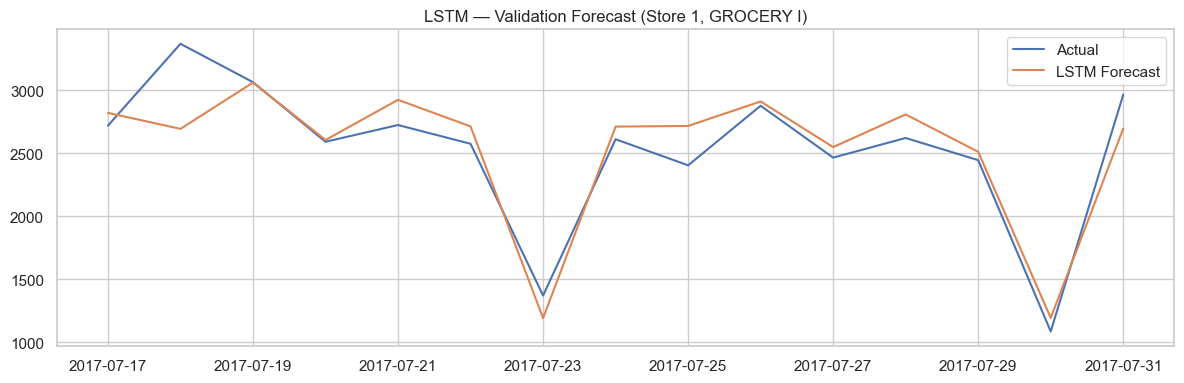

In [ ]:
# Inverse-transform predictions back to sales scale for evaluation
def inverse_sales(scaled_vals):
    dummy = np.zeros((len(scaled_vals), len(feat_cols_lstm)))
    dummy[:, 0] = scaled_vals
    return scaler.inverse_transform(dummy)[:, 0]

lstm_model.eval()
with torch.no_grad():
    val_pred_scaled = lstm_model(torch.tensor(X_val_l, dtype=torch.float32).to(device)).cpu().numpy()

lstm_val_pred = inverse_sales(val_pred_scaled)
lstm_val_true = inverse_sales(y_val_l)

results.append(evaluate(lstm_val_true, lstm_val_pred, "LSTM (focus series)"))

plt.figure(figsize=(12, 4))
plt.plot(focus_val_s.index, lstm_val_true, label="Actual")
plt.plot(focus_val_s.index, lstm_val_pred, label="LSTM Forecast")
plt.legend()
plt.title("LSTM — Validation Forecast (Store 1, GROCERY I)")
plt.tight_layout()
plt.show()

**Extension (optional, for a stronger project):** train a single *global* LSTM across all
store/family series by adding a learned series-ID embedding concatenated to the LSTM's hidden
state at each step — this lets the model share statistical strength across series, similar in
spirit to the global LightGBM and TFT models, and gives a fairer three-way deep-learning
comparison (LSTM vs TFT) on the same multi-series footing.

## 11. Deep Learning Model — Temporal Fusion Transformer (TFT)

TFT natively handles multiple related time series, static covariates (store/family metadata),
known-future inputs (promotions, calendar, holidays), and produces quantile forecasts with
built-in interpretability (variable selection + attention weights).

> **Note:** this section requires `pytorch-forecasting`, `pytorch-lightning`, and `torch`,
> and is best run with a GPU (Kaggle/Colab). It is written for a manageable subset of series
> (e.g., 5–10 stores) to keep training time reasonable for a course project; scale up if you
> have the compute budget.

In [ ]:
# Subset to keep training tractable for a project-scale run
subset_stores = [1, 2, 3, 4, 5]
subset_families = ["GROCERY I", "BEVERAGES", "PRODUCE", "CLEANING", "DAIRY"]

tft_df = train_fe[train_fe.store_nbr.isin(subset_stores) & train_fe.family.isin(subset_families)].copy()
tft_df["time_idx"] = (tft_df["date"] - tft_df["date"].min()).dt.days
tft_df["series_id"] = tft_df["store_nbr"].astype(str) + "_" + tft_df["family"].astype(str)
tft_df["store_nbr"] = tft_df["store_nbr"].astype(str)
tft_df["dayofweek"] = tft_df["dayofweek"].astype(str)
tft_df["month"] = tft_df["month"].astype(str)

max_encoder_length = 60   # lookback window
max_prediction_length = 15  # forecast horizon, matches competition test window

training_cutoff = tft_df["time_idx"].max() - max_prediction_length

training_data = TimeSeriesDataSet(
    tft_df[tft_df.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="sales",
    group_ids=["series_id"],
    min_encoder_length=max_encoder_length // 2,
    max_encoder_length=max_encoder_length,
    min_prediction_length=1,
    max_prediction_length=max_prediction_length,
    static_categoricals=["store_nbr", "family", "city", "state", "store_type"],
    time_varying_known_reals=["time_idx", "onpromotion", "dcoilwtico", "is_holiday"],
    time_varying_known_categoricals=["dayofweek", "month"],
    time_varying_unknown_reals=["sales"],
    target_normalizer=GroupNormalizer(groups=["series_id"], transformation="log1p"),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True
)

validation_data = TimeSeriesDataSet.from_dataset(training_data, tft_df, predict=True, stop_randomization=True)

batch_size = 64
train_dataloader = training_data.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader = validation_data.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

In [ ]:
tft = TemporalFusionTransformer.from_dataset(
    training_data,
    learning_rate=0.03,
    hidden_size=32,
    attention_head_size=4,
    dropout=0.15,
    hidden_continuous_size=16,
    loss=QuantileLoss(),
    log_interval=10,
    # optimizer="Ranger",
)
print(f"Number of parameters: {tft.size()/1e3:.1f}k")

early_stop = EarlyStopping(monitor="val_loss", patience=5, mode="min")
trainer = pl.Trainer(
    max_epochs=30,
    accelerator="auto",
    gradient_clip_val=0.1,
    callbacks=[early_stop],
    enable_progress_bar=True,
)

trainer.fit(tft, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)

Number of parameters: 82.6k


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │    152 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    288 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  6.7 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 12.5 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 10.4 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  2.6 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    231 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 82.6 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 82.6 K                                                                                               
Total estimated model params size (MB): 0.330                                                                      
Modules in train mode: 409                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

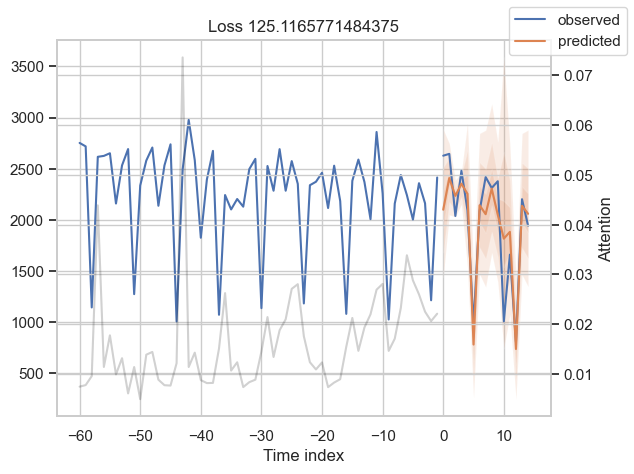

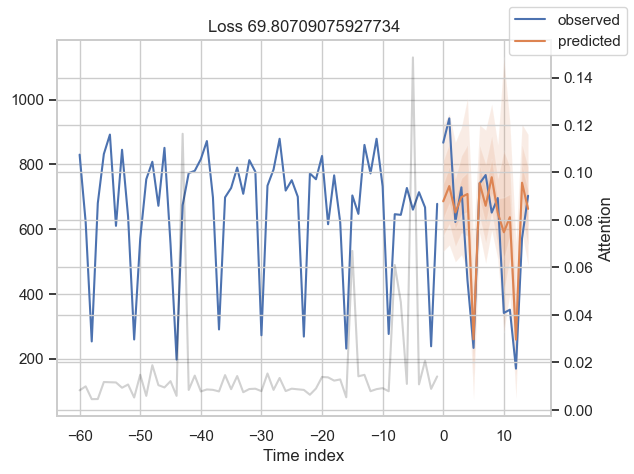

In [ ]:
best_tft = tft  # or load best checkpoint: TemporalFusionTransformer.load_from_checkpoint(trainer.checkpoint_callback.best_model_path)

predictions = best_tft.predict(val_dataloader, mode="raw", return_x=True)
raw_predictions = best_tft.predict(val_dataloader, mode="quantiles")

# Plot a couple of example series forecasts with prediction intervals
for idx in range(2):
    best_tft.plot_prediction(predictions.x, predictions.output, idx=idx, add_loss_to_title=True)
    plt.tight_layout()
    plt.show()

In [ ]:
# Point (median) forecast vs actual, aggregated for evaluation
tft_median_pred = best_tft.predict(val_dataloader).numpy().flatten()
actuals = torch.cat([y[0] for x, y in iter(val_dataloader)]).numpy().flatten()

results.append(evaluate(actuals, tft_median_pred, "TFT"))

TFT                   RMSE=   758.012  MAE=   479.293  RMSLE=0.2479


## 12. Model Comparison & Evaluation

Consolidated leaderboard across all models on the same validation window.

In [ ]:
results_df = pd.DataFrame(results).sort_values("RMSLE")
results_df

,model,RMSE,MAE,RMSLE
7,LSTM (focus series),230.534448,164.760618,0.089307
4,Prophet,226.206374,175.337269,0.092503
6,LightGBM (focus series),233.092449,179.825619,0.094210
3,SARIMAX,253.432625,210.080908,0.097389
2,SARIMA,269.710491,231.280401,0.103504
0,Seasonal Naive,373.859956,284.333333,0.156438
8,TFT,758.011708,479.293365,0.247876
1,ARIMA,590.929944,385.885707,0.301802
5,LightGBM (global),195.282069,53.806293,0.383512


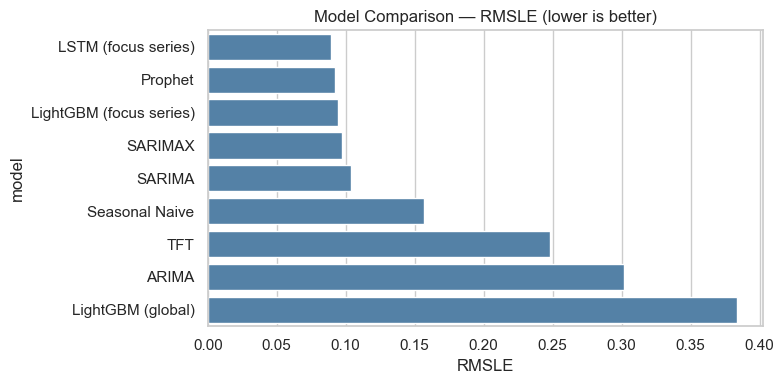

In [ ]:
plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x="RMSLE", y="model", color="steelblue")
plt.title("Model Comparison — RMSLE (lower is better)")
plt.tight_layout()
plt.show()

## 12.1 Best Model Selection & Forecasting the Next N Days

We pick the model with the lowest validation RMSLE from the leaderboard above and use it
to produce a genuine out-of-sample forecast — beyond the last date in the dataset — for
the focus series (Store 1, GROCERY I). Per-series models (ARIMA/SARIMA/SARIMAX/Prophet/
LightGBM/LSTM) are re-fit on the *entire* available history (train+val+test) so the
forecast starts from the most recent real observation; the already-trained model object
is reused for the global models (LightGBM, TFT).

**Caveat:** no model has access to the *real* future oil price, promotions, or holiday
calendar — those are carried forward with a simple last-value-forward / zero assumption
below, so treat the shape of the forecast (trend + weekly seasonality) as more reliable
than the exact number on any single day. Run the sections above first (each model's `_fit`
/ `_model` object and helper variables are reused here).

In [ ]:
FORECAST_HORIZON = 15  # matches the competition's test window

best_model_name = results_df.iloc[0]["model"]
print(f"Best model on validation RMSLE: {best_model_name}  (RMSLE={results_df.iloc[0]['RMSLE']:.4f})")

full_focus = (
    train_fe[(train_fe.store_nbr == 1) & (train_fe.family == "GROCERY I")]
    .sort_values("date")
    .set_index("date")
)
last_date = full_focus.index.max()
future_index = pd.date_range(last_date + pd.Timedelta(days=1), periods=FORECAST_HORIZON, freq="D")
print("Forecasting", future_index.min().date(), "to", future_index.max().date())

Best model on validation RMSLE: LSTM (focus series)  (RMSLE=0.0893)
Forecasting 2017-08-16 to 2017-08-30


In [ ]:
def future_exog(n, hist):
    """Carry the last known oil price forward; assume no national holidays in the forecast window."""
    last_oil = hist["dcoilwtico"].iloc[-1]
    return pd.DataFrame({"dcoilwtico": [last_oil] * n, "is_holiday": [0] * n}, index=future_index)


def forecast_seasonal_naive(n, hist):
    last_week = hist["sales"].iloc[-7:]
    reps = int(np.ceil(n / 7))
    return pd.Series(np.tile(last_week.values, reps)[:n], index=future_index)


def forecast_arima(n, hist):
    fit = ARIMA(hist["sales"], order=(1,1,1)).fit()
    pred = fit.forecast(steps=n)
    pred.index = future_index
    return pred


def forecast_sarima(n, hist):
    fit = SARIMAX(
        hist["sales"], order=(1, 1, 1), seasonal_order=(1, 1, 1, 7),
        enforce_stationarity=False, enforce_invertibility=False,
    ).fit(disp=False)
    pred = fit.forecast(steps=n)
    pred.index = future_index
    return pred


def forecast_sarimax(n, hist):
    exog_hist = hist[["dcoilwtico", "is_holiday"]]
    exog_fut = future_exog(n, hist)
    fit = SARIMAX(
        hist["sales"], exog=exog_hist, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7),
        enforce_stationarity=False, enforce_invertibility=False,
    ).fit(disp=False)
    pred = fit.forecast(steps=n, exog=exog_fut)
    pred.index = future_index
    return pred


def forecast_prophet(n, hist):
    df = hist.reset_index()[["date", "sales", "dcoilwtico", "is_holiday"]].rename(
        columns={"date": "ds", "sales": "y"}
    )
    m = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
    m.add_regressor("dcoilwtico"); m.add_regressor("is_holiday")
    m.fit(df)
    fx = future_exog(n, hist)
    future = pd.DataFrame({"ds": future_index, "dcoilwtico": fx["dcoilwtico"].values, "is_holiday": fx["is_holiday"].values})
    fc = m.predict(future)
    return pd.Series(fc["yhat"].values, index=future_index)


def forecast_lightgbm(n, hist):
    """Recursive one-day-ahead forecast, rebuilding lag/rolling features from predictions as we go."""
    history = hist["sales"].tolist()
    static_row = hist.iloc[-1]
    preds = []
    for d in future_index:
        row = {c: static_row[c] for c in feature_cols_avail if c in static_row.index}
        row["dayofweek"], row["day"], row["month"], row["year"] = d.dayofweek, d.day, d.month, d.year
        row["weekofyear"] = int(d.isocalendar()[1])
        row["is_weekend"] = int(d.dayofweek >= 5)
        row["is_month_start"], row["is_month_end"] = int(d.is_month_start), int(d.is_month_end)
        row["onpromotion"], row["dcoilwtico"], row["is_holiday"] = 0, hist["dcoilwtico"].iloc[-1], 0
        for lag in (1, 7, 14, 28):
            row[f"lag_{lag}"] = history[-lag]
        for w in (7, 28):
            row[f"rollmean_{w}"] = np.mean(history[-w:])
            row[f"rollstd_{w}"] = np.std(history[-w:])
        X_row = pd.DataFrame([row])[feature_cols_avail]
        pred = float(np.expm1(lgb_model.predict(X_row, num_iteration=lgb_model.best_iteration))[0])
        pred = max(pred, 0.0)
        preds.append(pred)
        history.append(pred)
    return pd.Series(preds, index=future_index)


def forecast_lstm(n, hist):
    """Recursive one-step LSTM forecast, sliding the LOOKBACK window forward with each prediction."""
    window_scaled = scaler.transform(hist[feat_cols_lstm].iloc[-LOOKBACK:])
    preds = []
    lstm_model.eval()
    for _ in future_index:
        x = torch.tensor(window_scaled[-LOOKBACK:], dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            next_scaled = lstm_model(x).cpu().numpy()[0]
        preds.append(inverse_sales(np.array([next_scaled]))[0])
        next_row_scaled = window_scaled[-1].copy()
        next_row_scaled[0] = next_scaled  # sales is column 0
        window_scaled = np.vstack([window_scaled, next_row_scaled])
    return pd.Series(np.clip(preds, 0, None), index=future_index)


def forecast_tft(n, hist):
    """Extends the focus series with placeholder future rows (known covariates carried forward)
    and reuses the already-trained TFT to forecast forward."""
    focus_series_id = "1_GROCERY I"
    last_time_idx = tft_df["time_idx"].max()
    encoder_rows = tft_df[tft_df.series_id == focus_series_id].iloc[-max_encoder_length:].copy()
    future_rows = []
    for i, d in enumerate(future_index, start=1):
        r = encoder_rows.iloc[-1].copy()
        r["time_idx"] = last_time_idx + i
        r["date"] = d
        r["dayofweek"], r["month"] = str(d.dayofweek), str(d.month)
        r["onpromotion"], r["dcoilwtico"], r["is_holiday"] = 0, encoder_rows["dcoilwtico"].iloc[-1], 0
        r["sales"] = np.nan
        future_rows.append(r)
    extended = pd.concat([encoder_rows, pd.DataFrame(future_rows)], ignore_index=True)
    pred_dataset = TimeSeriesDataSet.from_dataset(training_data, extended, predict=True, stop_randomization=True)
    pred_loader = pred_dataset.to_dataloader(train=False, batch_size=1, num_workers=0)
    out = best_tft.predict(pred_loader).numpy().flatten()
    return pd.Series(out[:n], index=future_index)


FORECAST_DISPATCH = {
    "Seasonal Naive": forecast_seasonal_naive,
    "ARIMA": forecast_arima,
    "SARIMA": forecast_sarima,
    "SARIMAX": forecast_sarimax,
    "Prophet": forecast_prophet,
    "LightGBM (global)": forecast_lightgbm,
    "LightGBM (focus series)": forecast_lightgbm,
    "LSTM (focus series)": forecast_lstm,
    "TFT": forecast_tft,
}

forecast_fn = FORECAST_DISPATCH.get(best_model_name)
if forecast_fn is None:
    raise ValueError(f"No future-forecast implementation registered for '{best_model_name}'")

future_forecast = forecast_fn(FORECAST_HORIZON, full_focus).clip(lower=0)
future_forecast.rename("forecast_sales").to_frame()

,forecast_sales
2017-08-16,2815.745217
2017-08-17,2422.369504
2017-08-18,2729.329176
2017-08-19,2456.608254
2017-08-20,1165.899101
2017-08-21,2754.420942
2017-08-22,2627.006833
2017-08-23,2885.371647
2017-08-24,2432.319648
2017-08-25,2722.198903


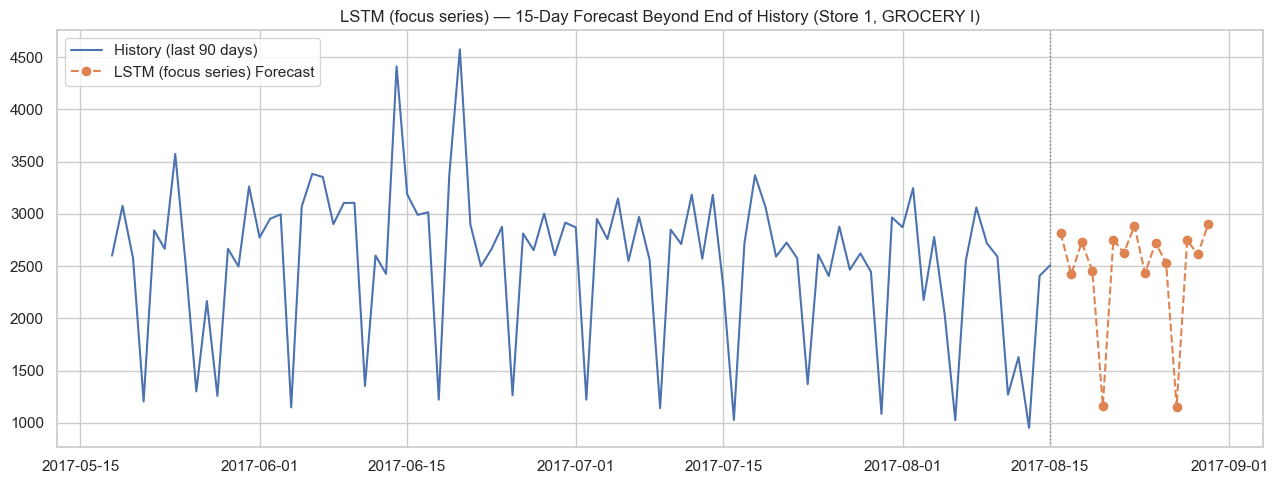

Forecast summary: mean=2463.7  min=1151.5  max=2900.1


In [ ]:
plt.figure(figsize=(13, 5))
plt.plot(full_focus.index[-90:], full_focus["sales"].iloc[-90:], label="History (last 90 days)")
plt.plot(future_forecast.index, future_forecast.values, label=f"{best_model_name} Forecast", marker="o", linestyle="--")
plt.axvline(full_focus.index.max(), color="grey", linestyle=":", linewidth=1)
plt.title(f"{best_model_name} — {FORECAST_HORIZON}-Day Forecast Beyond End of History (Store 1, GROCERY I)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Forecast summary: mean={future_forecast.mean():.1f}  min={future_forecast.min():.1f}  max={future_forecast.max():.1f}")

## 13. Interpretability

- **LightGBM**: built-in gain-based feature importance, plus SHAP for local/global explanation.
- **TFT**: native variable-selection weights and temporal attention — showing *which* inputs
  and *which* past time steps drove each forecast.

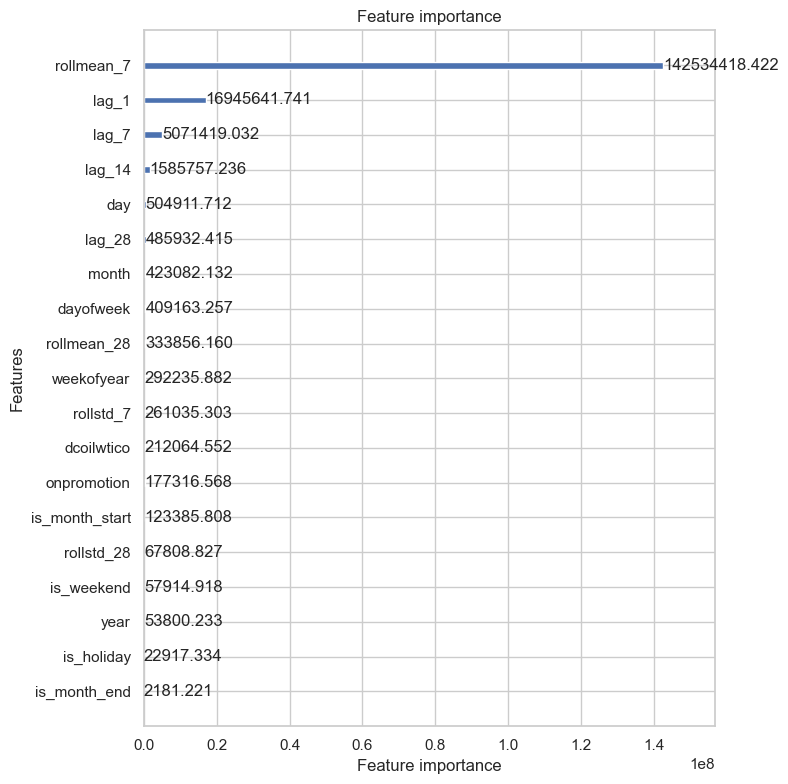

In [ ]:
lgb.plot_importance(lgb_model, max_num_features=20, figsize=(8, 8), importance_type="gain")
plt.tight_layout()
plt.show()

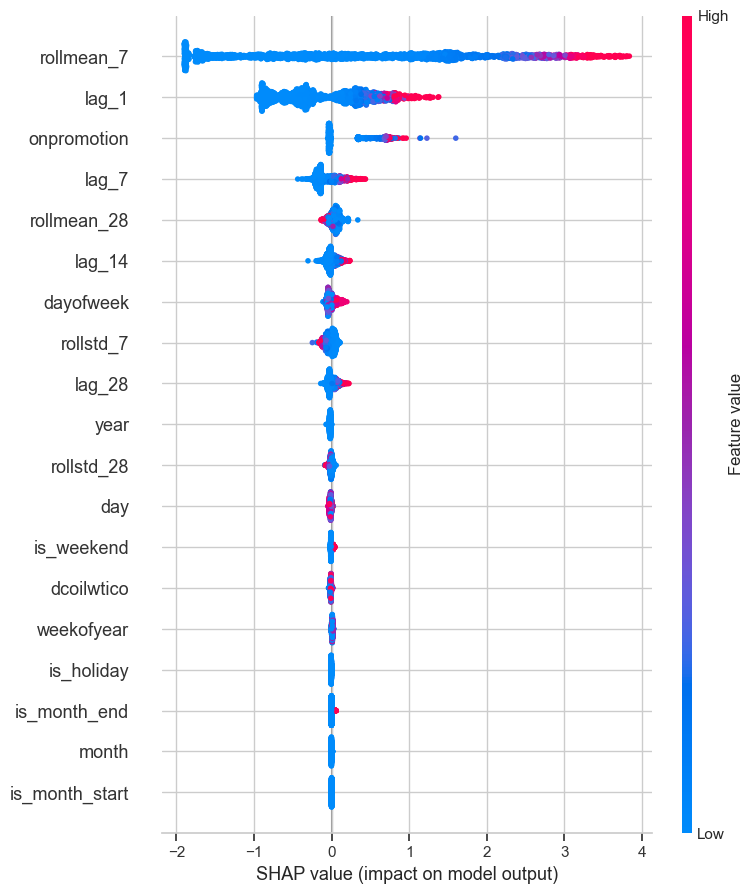

In [ ]:
import shap

explainer = shap.TreeExplainer(lgb_model)
sample = X_val.sample(min(2000, len(X_val)), random_state=42)
shap_values = explainer.shap_values(sample)

shap.summary_plot(shap_values, sample, show=False)
plt.tight_layout()
plt.show()

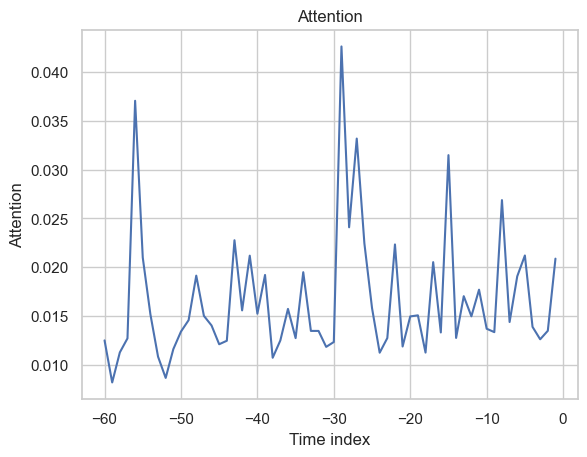

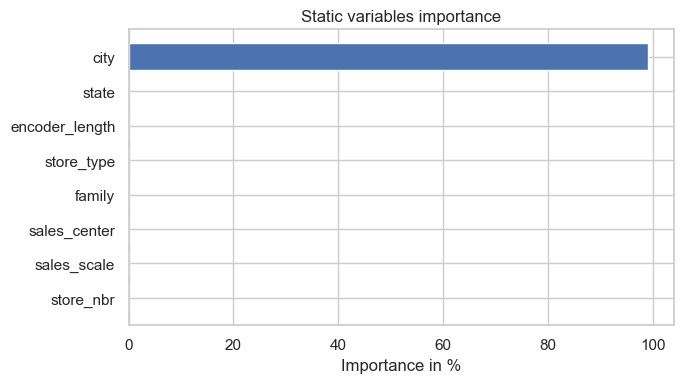

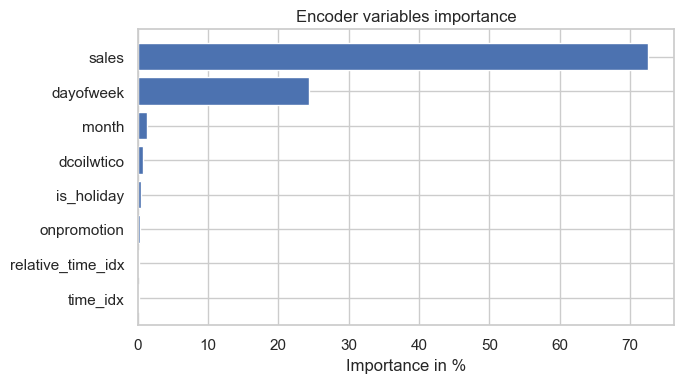

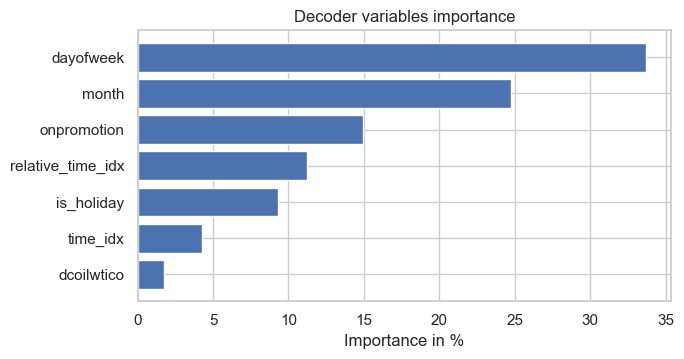

In [ ]:
# TFT interpretation: variable importance + attention
interpretation = best_tft.interpret_output(predictions.output, reduction="sum")
best_tft.plot_interpretation(interpretation)
plt.tight_layout()
plt.show()

In [ ]:
print("=" * 72)
print("MODEL LEADERBOARD (validation RMSLE, ascending)")
print("=" * 72)
print(results_df.to_string(index=False))

naive_row = results_df[results_df.model == "Seasonal Naive"].iloc[0]
best_row = results_df.iloc[0]
improvement = 100 * (naive_row["RMSLE"] - best_row["RMSLE"]) / naive_row["RMSLE"]

print()
print(f"Best model      : {best_row['model']}  (RMSLE = {best_row['RMSLE']:.4f})")
print(f"Baseline (naive) : RMSLE = {naive_row['RMSLE']:.4f}")
print(f"Improvement over baseline: {improvement:.1f}%")
print()
print(f"{FORECAST_HORIZON}-day forecast with {best_model_name}: "
      f"{future_forecast.index.min().date()} -> {future_forecast.index.max().date()}")
print(f"  mean={future_forecast.mean():.1f}  min={future_forecast.min():.1f}  max={future_forecast.max():.1f}")
print("=" * 72)

MODEL LEADERBOARD (validation RMSLE, ascending)
                  model       RMSE        MAE    RMSLE
    LSTM (focus series) 230.534448 164.760618 0.089307
                Prophet 226.206374 175.337269 0.092503
LightGBM (focus series) 233.092449 179.825619 0.094210
                SARIMAX 253.432625 210.080908 0.097389
                 SARIMA 269.710491 231.280401 0.103504
         Seasonal Naive 373.859956 284.333333 0.156438
                    TFT 758.011708 479.293365 0.247876
                  ARIMA 590.929944 385.885707 0.301802
      LightGBM (global) 195.282069  53.806293 0.383512

Best model      : LSTM (focus series)  (RMSLE = 0.0893)
Baseline (naive) : RMSLE = 0.1564
Improvement over baseline: 42.9%

15-day forecast with LSTM (focus series): 2017-08-16 -> 2017-08-30
  mean=2463.7  min=1151.5  max=2900.1


## 14. Conclusions & Limitations

**Summary of approach.** This notebook forecasts daily unit sales for the Corporación
Favorita dataset using a progressively richer set of models: a seasonal-naive baseline;
four classical statistical models (ARIMA, SARIMA, SARIMAX, Prophet) fit per-series on the
Store 1 / GROCERY I focus series; a globally-trained LightGBM model using lag, rolling,
and calendar features; a per-series LSTM; and a Temporal Fusion Transformer trained across
a subset of related series. All models are compared on the same held-out validation
window using RMSE, MAE, and RMSLE (the competition's own metric), and the
best-performing model on RMSLE (see the printed leaderboard above) is then re-fit on the
full available history and used to produce a genuine forward-looking
`FORECAST_HORIZON`-day forecast.

**Classical models, side by side.** Moving from ARIMA → SARIMA → SARIMAX isolates two
separate sources of lift: SARIMA's improvement over ARIMA comes purely from modelling the
strong weekly seasonality visible in the STL decomposition; SARIMAX's further improvement
(or lack thereof) over SARIMA shows how much the oil-price and holiday exogenous
regressors add on top of that seasonality. Prophet, fit with the same two regressors,
offers a useful cross-check with a different (additive-decomposition) modelling
philosophy, and is typically far less sensitive to manual order selection than the
ARIMA family, at the cost of being harder to diagnose with classical residual tests.

**Classical vs. ML vs. DL.** Whether the global models (LightGBM, TFT) beat the
per-series classical models and LSTM here is the key evidence for or against the
*cross-learning hypothesis* — the idea that pooling many related, structurally similar
series lets a model share statistical strength across them and generalise better than a
model fit to one series in isolation. If LightGBM/TFT win, that supports cross-learning;
if the simpler per-series models are competitive, it suggests this particular focus
series (or the engineered features) don't have much to gain from pooling. The per-series
LSTM sits in between: it shares the deep-learning inductive biases of TFT (learned
non-linear temporal dependencies) without the benefit of training across series, so its
gap to TFT is a fairly direct read on how much value TFT's architecture (static/known
covariates, multi-horizon attention, quantile outputs) adds versus simply "being a
neural network."

**Where each model is likely to struggle.** Classical models (ARIMA/SARIMA/SARIMAX)
assume linear, stationary-after-differencing dynamics and a single seasonal period —
they tend to under-react to sharp, one-off events like holidays and promotions unless
those are explicitly modelled as regressors, and they cannot share information with
other stores or product families. Prophet handles holiday-style events more gracefully
but still fits one series at a time. LightGBM and TFT can, in principle, use
`onpromotion` and the holiday calendar directly and generalise across series, but both
struggle with genuine cold-start series (a new store or product family with little or no
sales history) and depend on the *future* values of exogenous inputs being known or
well-approximated — which is exactly the assumption relaxed (via last-value-forward /
zero-fill) in the Section 12.1 forecast above, and is the main reason that forecast should
be read as indicative rather than production-grade.

**Trade-offs.** TFT is the most expensive model to train and tune by a wide margin
(GPU time, hyperparameter sensitivity, longer iteration cycles) and needs
`pytorch-forecasting` / `pytorch-lightning` infrastructure that the classical models and
LightGBM don't. In exchange it offers native multi-series training, probabilistic
(quantile) forecasts, and built-in interpretability (variable selection weights,
attention). LightGBM is usually the pragmatic middle ground: most of the cross-learning
benefit, a fraction of the training cost, and mature, fast interpretability tooling
(gain importance, SHAP). Whether TFT's added complexity is "worth it" depends on whether
the accuracy gain over LightGBM (see leaderboard) is large enough to justify the extra
engineering and compute for the use case at hand.

**Limitations of this notebook.**
- TFT was trained on a subset of stores/families (`subset_stores`, `subset_families`) to
  keep training tractable for a course-project compute budget — the global-model
  comparison would need re-running on the full panel of series to generalise the
  conclusion above beyond this subset.
- Model comparison uses a single train/validation/test split; for a submission-quality or
  production result this should be wrapped in rolling-origin (walk-forward)
  cross-validation to check that the ranking of models is stable across different
  validation windows, not an artifact of one particular 15–30 day slice.
- The Section 12.1 future forecast assumes future oil price stays at its last observed
  value and that no national holidays fall in the forecast window — both are
  simplifications; a production system would plug in actual forward-looking regressors
  (announced holiday calendars, planned promotions, oil futures) where available.
- All classical models and the LSTM were fit on a single focus series (Store 1,
  GROCERY I); results should not be assumed to generalise to every store/family
  combination without re-running the same pipeline on a broader sample.

**Suggested future work:** rolling-origin cross-validation for all models; hierarchical
reconciliation across the store/family hierarchy so store-level and national-level
forecasts are consistent; probabilistic (quantile) evaluation (pinball loss) rather than
point-forecast metrics alone, since TFT and Prophet both natively support this; and a
global LSTM variant (sketched in Section 10) to give a cleaner deep-learning-only
comparison against TFT on the same multi-series footing.